# Capire `dimer_exact.py` — guida interattiva

Questo notebook spiega **riga per riga** il modulo di benchmark esatto del dimero,
con celle eseguibili e qualche slider interattivo. L'obiettivo è rispondere in modo
operativo a tre domande:

1. **Cosa fa `SparsePauliOp`** in questo contesto, e perché è la *sorgente unica* di $H$?
2. **Perché uso `np.linalg.eigh` e non `np.linalg.eig`.**?
3. **Il `J` del codice** rispetto al $J = 4t^2/U$ della derivazione microscopica
   (`dimero_spin.pdf`)?

> **Come usarlo:** eseguire le celle dall'alto verso il basso. Serve un ambiente
> **Qiskit 2.x** con `numpy` e `matplotlib`; `ipywidgets` è opzionale (abilita gli slider,
> ma c'è sempre un fallback statico).

Il modello è
$$H = J\,(X_1X_2 + Y_1Y_2 + Z_1Z_2) + b\,(Z_1+Z_2) + D\,(X_1Z_2 - Z_1X_2),$$
isotropo nello scambio, con campo $b$ lungo $z$ e termine di Dzyaloshinskii–Moriya $D$.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp

# ipywidgets è opzionale: abilita gli slider. Se manca, usiamo un fallback statico.
try:
    from ipywidgets import interact, FloatSlider
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

print("Qiskit SparsePauliOp pronto. Slider interattivi:", "sì" if HAS_WIDGETS else "no (fallback statico)")

# Matrici di Pauli "a mano" (numpy), utili solo per i controlli incrociati di questo notebook
I2 = np.eye(2)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)

Qiskit SparsePauliOp pronto. Slider interattivi: sì


## 1. `SparsePauliOp`: la sorgente unica di $H$

`SparsePauliOp` rappresenta un operatore come **somma di stringhe di Pauli con coefficienti**:
$$H = \sum_k c_k\, P_k, \qquad P_k \in \{I,X,Y,Z\}^{\otimes n}.$$
Invece di scrivere a mano una matrice $4\times4$, dichiaro *quali* termini di Pauli ci sono e
*con che peso*. Due vantaggi pratici:

- **Una sola definizione di $H$** alimenta sia la diagonalizzazione esatta (`.to_matrix()` → matrice
  da dare a `eigh`) sia il VQE (l'oggetto va passato direttamente all'estimator). Niente rischio di
  due Hamiltoniane leggermente diverse nei due punti del codice.
- È la forma in cui il VQE *vuole* $H$: l'estimator misura $\langle H\rangle$ termine per termine.

### Convenzione delle label (importante)
In Qiskit la label si legge **da sinistra a destra come qubit $n{-}1,\dots,0$** (little-endian).
Quindi `"ZI"` = $Z$ sul **qubit 1**, $I$ sul **qubit 0**, cioè $Z_1\otimes I_0$. Il modello è
simmetrico per scambio dei due spin, quindi $Z_1+Z_2$ si scrive `"ZI" + "IZ"`.

Mappa dei 7 termini del dimero:

| label | coeff. | termine fisico |
|-------|--------|----------------|
| `XX`, `YY`, `ZZ` | `J`, `J`, `J` | scambio isotropo $J(X_1X_2+Y_1Y_2+Z_1Z_2)$ |
| `ZI`, `IZ` | `b`, `b` | campo (Zeeman) $b(Z_1+Z_2)$ |
| `XZ`, `ZX` | `D`, `-D` | Dzyaloshinskii–Moriya $D(X_1Z_2 - Z_1X_2)$ |

In [2]:
def dimer_hamiltonian(b, J=1.0, D=0.0):
    # H(b) come SparsePauliOp per dati J, D
    labels = ["XX", "YY", "ZZ", "ZI", "IZ", "XZ", "ZX"]
    coeffs = [J, J, J, b, b, D, -D]
    return SparsePauliOp(labels, coeffs)

H = dimer_hamiltonian(b=1.0, J=1.0, D=0.2)
print(H)            # mostra le stringhe di Pauli e i coefficienti
print("\nNumero di termini:", len(H))

SparsePauliOp(['XX', 'YY', 'ZZ', 'ZI', 'IZ', 'XZ', 'ZX'],
              coeffs=[ 1. +0.j,  1. +0.j,  1. +0.j,  1. +0.j,  1. +0.j,  0.2+0.j, -0.2+0.j])

Numero di termini: 7


La cella sopra stampa l'operatore *simbolico*. Con `.to_matrix()` lo trasformiamo nella
matrice $4\times4$ concreta — quella che daremo a `eigh`. Notare che è **hermitiana**
($H = H^\dagger$): è il presupposto della prossima sezione.

In [3]:
M = H.to_matrix()
print("Forma:", M.shape, " dtype:", M.dtype)
print("Hermitiana? ", np.allclose(M, M.conj().T))
np.set_printoptions(precision=2, suppress=True)
print(M.real)   # qui la parte immaginaria è nulla (si veda nota sotto)

Forma: (4, 4)  dtype: complex128
Hermitiana?  True
[[ 3.  -0.2  0.2  0. ]
 [-0.2 -1.   2.  -0.2]
 [ 0.2  2.  -1.   0.2]
 [ 0.  -0.2  0.2 -1. ]]


### Controllo della convenzione delle label
Verifichiamo esplicitamente che `"ZI"` $= Z\otimes I$ e che `"ZI"+"IZ"` riproduce $Z_1+Z_2$
(diagonale $(+2,0,0,-2)$ nella base $|q_1 q_0\rangle = |00\rangle,|01\rangle,|10\rangle,|11\rangle$).

In [4]:
ZI = SparsePauliOp(["ZI"], [1.0]).to_matrix()
IZ = SparsePauliOp(["IZ"], [1.0]).to_matrix()
print("ZI == kron(Z, I)? ", np.allclose(ZI, np.kron(Z, I2)))
print("IZ == kron(I, Z)? ", np.allclose(IZ, np.kron(I2, Z)))
print("\nZ1 + Z2 (diagonale):", np.diag((ZI + IZ).real))

# Il termine DM è antisimmetrico: XZ - ZX
DM = SparsePauliOp(["XZ", "ZX"], [1.0, -1.0]).to_matrix()
print("\nDM = X1Z2 - Z1X2 :\n", DM.real)

ZI == kron(Z, I)?  True
IZ == kron(I, Z)?  True

Z1 + Z2 (diagonale): [ 2.  0.  0. -2.]

DM = X1Z2 - Z1X2 :
 [[ 0. -1.  1.  0.]
 [-1.  0.  0. -1.]
 [ 1.  0.  0.  1.]
 [ 0. -1.  1.  0.]]


**Slider:** osservo come cambia la matrice di $H$ al variare di $b$ e $D$.
Il campo $b$ tocca solo la diagonale (Zeeman); $D$ accende gli elementi fuori diagonale
che mescolano settori con $M$ diverso (il meccanismo dell'anticrossing).

In [ ]:
def show_matrix(b=1.0, D=0.2):
    M = dimer_hamiltonian(b=b, J=1.0, D=D).to_matrix().real
    fig, ax = plt.subplots(figsize=(3.6, 3.6))
    im = ax.imshow(M, cmap="coolwarm", vmin=-3, vmax=5)
    for (i, j), val in np.ndenumerate(M):
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    labels = [r"$|00\rangle$", r"$|01\rangle$", r"$|10\rangle$", r"$|11\rangle$"]
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_title(f"H  (b={b:.2f}, D={D:.2f})")
    plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    interact(show_matrix,
             b=FloatSlider(min=0, max=5, step=0.25, value=1.0),
             D=FloatSlider(min=0, max=0.6, step=0.05, value=0.2))
else:
    show_matrix(1.0, 0.2)

interactive(children=(FloatSlider(value=1.0, description='b', max=5.0, step=0.25), FloatSlider(value=0.2, desc…

## 2. Perché `eigh` e non `eig`

`numpy` ha due routine di diagonalizzazione:

- **`np.linalg.eig`** — per matrici **generiche** (anche non simmetriche). Non assume nulla.
- **`np.linalg.eigh`** — per matrici **hermitiane** ($H=H^\dagger$) / simmetriche reali. Sfrutta
  questa proprietà.

Un'Hamiltoniana è *sempre* hermitiana, quindi posso usare correttamente `eigh`. Cosa garantisce in più:

| | `eig` (generico) | `eigh` (hermitiano) |
|---|---|---|
| autovalori reali | non garantito (dtype complesso) | **sì, reali** |
| **ordinamento** | arbitrario | **crescente** |
| autovettori ortonormali | non garantito | **sì** |
| accuratezza/stabilità | generica | migliore (usa la struttura) |

La conseguenza pratica di interesse: con `eigh`, il **ground state è sempre `w[0]`, `v[:,0]`**,
senza dover cercare il minimo. Con `eig` l'ordine è casuale e bisognerebbe fare `argmin`
(ed estrarre la parte reale).

In [6]:
H = dimer_hamiltonian(b=1.0, J=1.0, D=0.0).to_matrix()
# a b=1, J=1, D=0 lo spettro atteso è {-3 (singoletto), -1, 1, 3 (tripletto J-2b, J, J+2b)}

w_eig,  v_eig  = np.linalg.eig(H)
w_eigh, v_eigh = np.linalg.eigh(H)

print("eig  -> autovalori (ordine ARBITRARIO):", np.round(w_eig, 3))
print("eigh -> autovalori (ordine CRESCENTE) :", np.round(w_eigh, 3))
print()
print("Con eigh il ground state è subito w[0] =", round(float(w_eigh[0]), 3))
print("Con eig dovresti fare argmin: w[", int(np.argmin(w_eig.real)), "] =",
      round(float(w_eig.real[np.argmin(w_eig.real)]), 3))

eig  -> autovalori (ordine ARBITRARIO): [ 1.+0.j -3.+0.j  3.+0.j -1.+0.j]
eigh -> autovalori (ordine CRESCENTE) : [-3. -1.  1.  3.]

Con eigh il ground state è subito w[0] = -3.0
Con eig dovresti fare argmin: w[ 1 ] = -3.0


In [7]:
# Ortonormalità degli autovettori: V^dagger V deve fare l'identità
err_eigh = np.linalg.norm(v_eigh.conj().T @ v_eigh - np.eye(4))
print("eigh: || V^H V - I || =", f"{err_eigh:.1e}   (ortonormali)")

# dtype: eig restituisce in generale array complessi, eigh sempre reali
print("dtype autovalori   eig:", w_eig.dtype, "  eigh:", w_eigh.dtype)

eigh: || V^H V - I || = 3.2e-16   (ortonormali)
dtype autovalori   eig: complex128   eigh: float64


**Nota sul caso complesso.** Qui $H$ risulta reale simmetrica (anche il termine DM lungo $\hat y$
dà una matrice reale), quindi `eig` non sbaglia di molto. Ma in generale un'Hamiltoniana è
**complessa hermitiana** (p.es. un campo trasverso lungo $y$, o un DM lungo $\hat x$): allora `eig`
può restituire autovalori con piccole parti immaginarie spurie, mentre `eigh` resta esatto.
Per un'Hamiltoniana, `eigh` è la scelta giusta *sempre* — non solo qui.

## 3. Il `J` del codice vs il $J = 4t^2/U$ della derivazione

**Il `J` del codice è il coefficiente della somma di Pauli $X_1X_2+Y_1Y_2+Z_1Z_2$, non il
coefficiente di $\mathbf{s}_1\!\cdot\!\mathbf{s}_2$. I due differiscono per un fattore 4.**

La catena (Appendice B di `dimero_spin.pdf`):

1. **Microscopico (Hubbard efficace).** La derivazione dà
   $$H_{\text{ex}} = J_{\text{H}}\,\mathbf{s}_1\!\cdot\!\mathbf{s}_2, \qquad J_{\text{H}} = \frac{4t^2}{U}.$$
   Qui $J_{\text{H}}$ è il coefficiente di $\mathbf{s}_1\!\cdot\!\mathbf{s}_2$.

2. **Passaggio ai Pauli.** Con $\mathbf{s}_i = \tfrac12\boldsymbol\sigma_i$ si ha
   $\mathbf{s}_1\!\cdot\!\mathbf{s}_2 = \tfrac14(X_1X_2+Y_1Y_2+Z_1Z_2)$, quindi
   $$H_{\text{ex}} = \frac{J_{\text{H}}}{4}\,(X_1X_2+Y_1Y_2+Z_1Z_2).$$

3. **Codice / 6-Applications.** Lì si scrive $H_1 = J_{\text{code}}\,(X_1X_2+Y_1Y_2+Z_1Z_2)$.
   Confrontando con il punto 2:
   $$\boxed{\,J_{\text{code}} = \frac{J_{\text{H}}}{4} = \frac{t^2}{U}\,}$$

Quindi il `J` che passo a `dimer_hamiltonian` è $J_{\text{code}}$. Lo **spettro analitico**
$E(S,M) = 2J\,S(S+1) - 3J + 2bM$ usa anch'esso $J_{\text{code}}$, perché
$H_1 = J_{\text{code}}(X_1X_2+Y_1Y_2+Z_1Z_2) = 2J_{\text{code}}\,S(S+1) - 3J_{\text{code}}$.

| quantità | simbolo | valore | dove |
|---|---|---|---|
| coeff. di $\mathbf{s}_1\!\cdot\!\mathbf{s}_2$ | $J_{\text{H}}$ | $4t^2/U$ | `dimero_spin.pdf`, eq. (26) |
| coeff. di $(X_1X_2+Y_1Y_2+Z_1Z_2)$ — **il `J` del codice** | $J_{\text{code}}$ | $t^2/U = J_{\text{H}}/4$ | App. B, codice |

Impostare `J=1.0` nel codice significa $J_{\text{code}}=1$, cioè $J_{\text{H}}=4$, cioè $t^2/U=1$.
Le energie sono misurate in unità di $J_{\text{code}}$ e l'unico parametro fisico è il rapporto
adimensionale $b/J$.

In [8]:
def J_from_hubbard(t, U):
    J_H    = 4 * t**2 / U      # coefficiente di s1.s2  (derivazione)
    J_code = t**2 / U          # coefficiente di (XX+YY+ZZ) = J_H/4  (codice)
    return J_H, J_code

t, U = 1.0, 4.0                 # esempio: regime di Mott richiede U >> t
J_H, J_code = J_from_hubbard(t, U)
print(f"t={t}, U={U}  ->  J_H = 4t^2/U = {J_H:.3f}   |   J_code = t^2/U = {J_code:.3f}")
print(f"Verifica  J_code == J_H/4 :", np.isclose(J_code, J_H / 4))

t=1.0, U=4.0  ->  J_H = 4t^2/U = 1.000   |   J_code = t^2/U = 0.250
Verifica  J_code == J_H/4 : True


In [9]:
# Verifica numerica: con J = J_code, lo spettro a b=0 è singoletto -3J, tripletto +J (3 volte)
for Jc in [1.0, J_code]:
    w = np.linalg.eigvalsh(dimer_hamiltonian(b=0.0, J=Jc, D=0.0).to_matrix())
    print(f"J_code={Jc:.3f}  ->  spettro a b=0:", np.round(w, 3),
          f"   (atteso: -3J={-3*Jc:.3f}, +J={Jc:.3f} x3)")

J_code=1.000  ->  spettro a b=0: [-3.  1.  1.  1.]    (atteso: -3J=-3.000, +J=1.000 x3)
J_code=0.250  ->  spettro a b=0: [-0.75  0.25  0.25  0.25]    (atteso: -3J=-0.750, +J=0.250 x3)


**Slider:** muovo $t$ e $U$ e osservo $J_{\text{code}}$ e lo spettro a $b=0$. Tiengo $U \gg t$
(regime in cui la mappatura a soli spin è valida). Si vede che la *forma* dello spettro è sempre
la stessa: cambia solo la scala $J_{\text{code}}$.

In [10]:
def show_J(t=1.0, U=8.0):
    J_H, J_code = J_from_hubbard(t, U)
    w = np.linalg.eigvalsh(dimer_hamiltonian(b=0.0, J=J_code, D=0.0).to_matrix())
    print(f"J_H = {J_H:.4f} (coeff. s1.s2)   J_code = {J_code:.4f} (coeff. XX+YY+ZZ)   "
          f"t/U = {t/U:.3f}")
    print("spettro a b=0:", np.round(w, 4))

if HAS_WIDGETS:
    interact(show_J,
             t=FloatSlider(min=0.2, max=2.0, step=0.1, value=1.0),
             U=FloatSlider(min=2.0, max=20.0, step=0.5, value=8.0))
else:
    show_J(1.0, 8.0)

interactive(children=(FloatSlider(value=1.0, description='t', max=2.0, min=0.2), FloatSlider(value=8.0, descri…

## 4. Il resto del modulo: `exact_sweep`, `_self_test`, la figura

Con i tre mattoni chiari (sorgente `SparsePauliOp`, `eigh`, significato di `J`), assemblo. `exact_sweep` scorre una griglia di campo $b$ e per ciascun valore:

1. costruisce $H$ con `dimer_hamiltonian` e lo rende matrice (`.to_matrix()`);
2. diagonalizza con `eigh` → autovalori `w` (ordinati) e autovettori `v`;
3. il **ground state** è `g = v[:,0]`; la sua energia è `w[0]`;
4. calcola la **magnetizzazione** $\langle M_z\rangle = g^\dagger M_z\, g$ con
   $M_z = (Z_1+Z_2)/2$, anch'esso un `SparsePauliOp`.

In [11]:
def magnetization_operator():
    # Mz = (Z1 + Z2) / 2
    return SparsePauliOp(["ZI", "IZ"], [0.5, 0.5])

def analytic_eigenvalues(b, J=1.0):
    # Spettro esatto del caso isotropo (D=0): singoletto + tripletto M=+1,0,-1
    return np.sort([-3.0 * J, J + 2.0 * b, J, J - 2.0 * b])

def exact_sweep(b_values, J=1.0, D=0.0):
    Mz = magnetization_operator().to_matrix()
    energies, gs_energy, gs_state, gs_mz = [], [], [], []
    for b in b_values:
        H = dimer_hamiltonian(b, J, D).to_matrix()
        w, v = np.linalg.eigh(H)          # hermitiana: reali e ordinati
        g = v[:, 0]                        # ground state = primo autovettore
        energies.append(w)
        gs_energy.append(w[0])
        gs_state.append(g)
        gs_mz.append(np.real(g.conj() @ Mz @ g))
    return {"b": np.asarray(b_values),
            "energies": np.asarray(energies),
            "gs_energy": np.asarray(gs_energy),
            "gs_state": np.asarray(gs_state),
            "gs_mz": np.asarray(gs_mz)}

print("Funzioni definite.")

Funzioni definite.


### Il self-test (controllo di qualità)
`analytic_eigenvalues` dà lo spettro in forma chiusa per $D=0$. `_self_test` confronta numerico
vs analitico su 200 punti e pretende un errore $< 10^{-10}$. C'è un rumore di arrotondamento a precisione macchina (l'`float64` ha $\varepsilon \approx 2.2\times10^{-16}$),
introdotto dall'assemblaggio della matrice in `.to_matrix()`. Nessuna discrepanza fisica: lo spettro
numerico **è** quello analitico.

In [12]:
def self_test(J=1.0):
    b = np.linspace(0.0, 5.0, 200)
    res = exact_sweep(b, J=J, D=0.0)
    err = max(np.max(np.abs(np.sort(res["energies"][i]) - analytic_eigenvalues(bv, J)))
              for i, bv in enumerate(b))
    print(f"[self-test] max|E_num - E_analitico| (D=0) = {err:.2e}")
    assert err < 1e-10, "spettro numerico non coincide con l'analitico"
    print("OK: entro tolleranza.")

self_test()

[self-test] max|E_num - E_analitico| (D=0) = 8.88e-16
OK: entro tolleranza.


### La figura del modulo
Riproduco i due pannelli: spettro $E/J$ (con i quattro livelli, GS per $D=0$ e $D=0.2$) e
magnetizzazione $\langle M_z\rangle$ (gradino vs crossover).

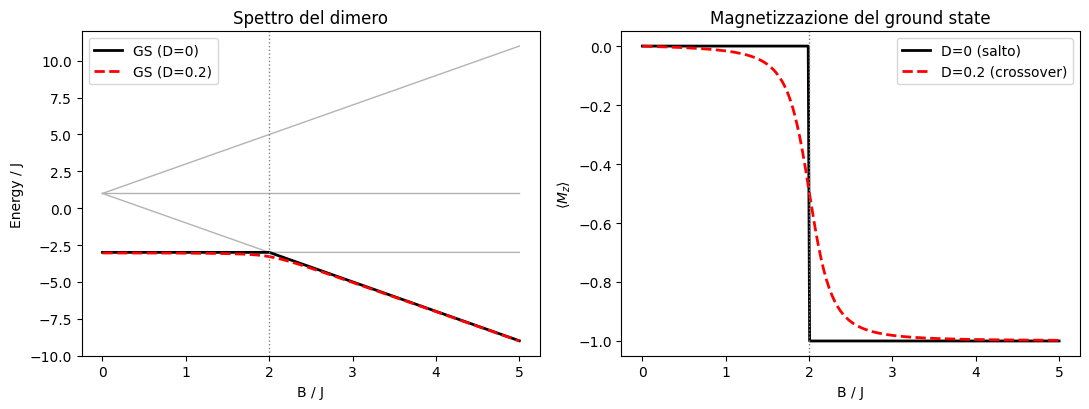

In [13]:
J = 1.0
b = np.linspace(0.0, 5.0, 300)
res0 = exact_sweep(b, J=J, D=0.0)
resD = exact_sweep(b, J=J, D=0.2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for k in range(4):
    ax1.plot(b / J, res0["energies"][:, k], color="0.7", lw=1)
ax1.plot(b / J, res0["gs_energy"], "k", lw=2, label="GS (D=0)")
ax1.plot(b / J, resD["gs_energy"], "r--", lw=2, label="GS (D=0.2)")
ax1.axvline(2.0, color="0.5", ls=":", lw=1)
ax1.set_xlabel("B / J"); ax1.set_ylabel("Energy / J")
ax1.set_title("Spettro del dimero"); ax1.legend()

ax2.plot(b / J, res0["gs_mz"], "k", lw=2, label="D=0 (salto)")
ax2.plot(b / J, resD["gs_mz"], "r--", lw=2, label="D=0.2 (crossover)")
ax2.axvline(2.0, color="0.5", ls=":", lw=1)
ax2.set_xlabel("B / J"); ax2.set_ylabel(r"$\langle M_z \rangle$")
ax2.set_title("Magnetizzazione del ground state"); ax2.legend()
plt.tight_layout(); plt.show()

**Slider:** accendo $D$ da 0 e guardo l'incrocio in $B/J=2$ trasformarsi in anticrossing
(zoom sul fondamentale).

In [14]:
def show_crossing(D=0.0):
    b = np.linspace(1.5, 2.5, 200)
    res = exact_sweep(b, J=1.0, D=D)
    plt.figure(figsize=(6, 4))
    plt.plot(b, res["energies"][:, 0], "k", lw=2, label="GS")
    plt.plot(b, res["energies"][:, 1], "0.6", lw=1.2, label="1° eccitato")
    plt.axvline(2.0, color="0.7", ls=":")
    gap2 = (exact_sweep([2.0], J=1.0, D=D)["energies"][0][1]
            - exact_sweep([2.0], J=1.0, D=D)["energies"][0][0])
    plt.title(f"D = {D:.2f}   |   gap a B/J=2 = {gap2:.3f}")
    plt.xlabel("B / J"); plt.ylabel("E / J"); plt.legend(); plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    interact(show_crossing, D=FloatSlider(min=0.0, max=0.6, step=0.05, value=0.2))
else:
    show_crossing(0.2)

interactive(children=(FloatSlider(value=0.2, description='D', max=0.6, step=0.05), Output()), _dom_classes=('w…

## 5. Il passo successivo (VQE)

Lo scheletro VQE lo costruisco **sopra** questo modulo:

- la stessa `dimer_hamiltonian(...)` (`SparsePauliOp`) si passa all'**estimator**, che misura
  $\langle H\rangle_{\boldsymbol\theta}$ da minimizzare — niente seconda definizione di $H$;
- `exact_sweep` fornisce il **riferimento**: energia esatta del fondamentale $E_0(b)$ e stato
  $|\psi_0(b)\rangle$ (da `v[:,0]`), contro cui misurare l'errore di energia e la **fidelity**
  $\mathcal F = |\langle\psi_0|\psi(\tilde{\boldsymbol\theta})\rangle|$;
- aver scelto `eigh` garantisce che quel riferimento sia corretto e univoco (GS = `w[0]`, `v[:,0]`).

In breve: questo modulo è il *metro* con cui vado a giudicare il VQE.

## 6. Riepilogo — le tre risposte

1. **`SparsePauliOp`** dichiara $H$ come somma di stringhe di Pauli con coefficienti. È la
   *sorgente unica*: `.to_matrix()` alimenta la diagonalizzazione esatta, l'oggetto stesso
   alimenta il VQE. Le label sono little-endian (`"ZI"` = $Z$ sul qubit 1).

2. **`eigh`** perché $H$ è hermitiana: `eigh` garantisce autovalori **reali e
   ordinati in modo crescente** e autovettori **ortonormali**, così il ground state è
   direttamente `w[0]`, `v[:,0]`. `eig` è per matrici generiche, non ordina e può introdurre
   parti immaginarie spurie.

3. **Il `J` del codice** è il coefficiente di $(X_1X_2+Y_1Y_2+Z_1Z_2)$, cioè
   $J_{\text{code}} = t^2/U = J_{\text{H}}/4$, dove $J_{\text{H}} = 4t^2/U$ è il coefficiente di
   $\mathbf{s}_1\!\cdot\!\mathbf{s}_2$ nella derivazione. Differiscono per un fattore 4 (Appendice B).
   `J=1.0` è solo una scelta di unità; la fisica dipende da $b/J$.